# Three-player Hold'em production training and strategy laboratory

This notebook is the control plane for a long-running, resumable CUDA training campaign. It trains three advantage networks and three deployable average-policy networks, evaluates strength every **N** iterations, promotes validation champions, maintains a historical opponent league, and produces exact 169-hand policy-frequency charts for named game situations.

The default `tournament_production` profile targets 10,000 iterations in a new artifact directory and trains variable-stack three-handed/heads-up roots. Stopping the cell with `Ctrl+C` creates an emergency full checkpoint; rerunning the notebook resumes from the latest recoverable iteration.

## What this notebook can—and cannot—prove

A falling neural-network loss is not evidence that the bot is better at poker. The strength dashboard therefore uses fixed validation deals against uniform-random, calling-station, and card-aware tight-aggressive opponents; paired change versus the initial policy; confidence intervals; per-position EV; and matches against frozen historical policies.

Three-player poker is not two-player zero-sum, so these measurements are not exact exploitability or a Nash-convergence proof. The bot can be described as beating humans only after a sufficiently large, held-out human match with seat rotation and an uncertainty interval above zero. The current engine also uses nine discrete betting actions, so a human match must use the same abstraction or add a separately validated bet-translation layer.

> Every card chart below is a **policy action frequency**, not hand equity and not probability of winning.

In [1]:
%matplotlib inline
from pathlib import Path
import math
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import clear_output, display

from three_player_engine import ACTION_NAMES
from three_player_native import ThreePlayerHoldemEnv
from three_player_production import (
    CampaignConfig, ProductionCampaign, evaluate_benchmark_suite,
    load_or_create_trainer, metrics_frame, plot_training_dashboard,
)
from three_player_analysis import (
    StrategyAnalyzer, compare_ranges, plot_call_maps, plot_card_sweep,
    plot_network_architecture,
    plot_range_delta, plot_range_heatmaps, postflop_scenarios,
    preflop_scenarios,
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

## 1. Validate the engine, trainer, production workflow, and range analysis

These tests include side pots and zero-sum settlement, elimination/heads-up tournament flow, variable-stack roots and warm starts, CUDA checkpoint continuation, legal scenario replay, all 1,326 physical preflop combinations, postflop blockers, policy snapshots, and campaign resume. Set `POKER_RUN_TESTS=0` only after the environment is known-good.

In [2]:
RUN_SELF_TESTS = os.getenv('POKER_RUN_TESTS', '1') == '1'
if RUN_SELF_TESTS:
    subprocess.run(
        [sys.executable, '-m', 'unittest', '-q',
         'test_three_player_engine.py', 'test_three_player_training.py',
         'test_tournament_training.py',
         'test_three_player_tournament.py', 'test_tournament_engine.py',
         'test_three_player_analysis.py', 'test_native_engine.py'],
        check=True,
    )
    print('All engine, CUDA, production, and analysis tests passed.')
else:
    print('Self-tests skipped by POKER_RUN_TESTS=0.')

All engine, CUDA, production, and analysis tests passed.


## 2. Require and describe the CUDA device

In [3]:
if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required. Install a CUDA-enabled PyTorch build and a compatible NVIDIA driver.')
DEVICE = torch.device('cuda:0')
torch.set_float32_matmul_precision('high')
gpu = torch.cuda.get_device_properties(DEVICE)
display(pd.Series({
    'PyTorch': torch.__version__,
    'device': str(DEVICE),
    'GPU': gpu.name,
    'VRAM GiB': gpu.total_memory / 1024**3,
    'CUDA capability': f'{gpu.major}.{gpu.minor}',
}, name='hardware'))

PyTorch                                  2.11.0+cu128
device                                         cuda:0
GPU                NVIDIA GeForce RTX 3050 Laptop GPU
VRAM GiB                                     3.999512
CUDA capability                                   8.6
Name: hardware, dtype: object

## 3. Persisted production configuration

The default tournament profile is sized as a serious starting campaign for this machine's 4-GiB GPU and 16-GiB system memory. The reservoirs remain in CPU memory; batched network fitting and range inference use CUDA. The recursive game-tree traversal is still latency-bound, so phase timing and rollout cutoffs are monitored explicitly.

The default is `tournament_production`: a fresh dual-attention/state-memory run with no warm start. Increase `POKER_TARGET_ITERATION` to extend this same run later. `POKER_RANGE_EVERY_EVALS=1` refreshes the full hand charts after every completed evaluation.

In [4]:
PROFILE = os.getenv('POKER_TRAINING_PROFILE', 'tournament_production').strip().lower()
DEFAULT_CPU_WORKERS = 12 if PROFILE.endswith('production') else 1
REQUESTED_CPU_WORKERS = int(os.getenv('POKER_CPU_WORKERS', str(DEFAULT_CPU_WORKERS)))
CPU_WORKERS = max(1, min(REQUESTED_CPU_WORKERS, 12))
if CPU_WORKERS != REQUESTED_CPU_WORKERS:
    print(f'Clamped POKER_CPU_WORKERS={REQUESTED_CPU_WORKERS} to this machine’s physical-core range 1..12')
PROFILES = {
    'production': {
        'artifact_dir': Path('artifacts/three_player_production'),
        'environment': {'stack_size': 200, 'sb': 1, 'bb': 2, 'seed': 42},
        'trainer': {
            'hidden': 256, 'blocks': 1, 'learning_rate': 3e-4,
            'advantage_capacity': 150_000, 'policy_capacity': 150_000,
            'max_history': 32, 'max_nodes_per_traversal': 20_000,
            'max_depth': 64, 'max_strategy_importance': 100.0,
            'exploration': 0.02,
            'include_tournament_features': False,
            'variable_stack_training': False,
            'reinitialize_advantage_each_iteration': True, 'seed': 42,
        },
        'campaign': {
            'target_iteration': 10_000, 'traversals_per_player': 3,
            'advantage_steps': 64, 'policy_steps': 32, 'batch_size': 512,
            'evaluate_every': 2, 'checkpoint_every': 25,
            'snapshot_every': 100, 'evaluation_games_per_player': 300,
            'league_games_per_player': 99, 'validation_seed': 202_700,
            'opponent_profiles': ('random', 'calling_station', 'tight_aggressive'),
            'league_opponents': 3,
        },
        'warm_start_policy': None,
    },
    'tournament_production': {
        'artifact_dir': Path('artifacts/three_player_tournament_deep_cfr_bootstrap25_v1'),
        'environment': {'stack_size': 200, 'sb': 1, 'bb': 2, 'seed': 442},
        'trainer': {
            'hidden': 128, 'blocks': 3, 'network_architecture': 'deep_cfr_branch_v2',
            'learning_rate': 1e-3,
            'advantage_capacity': 700_000, 'policy_capacity': 700_000,
            'max_history': 32, 'max_nodes_per_traversal': 5_000,
            'max_depth': 32, 'max_strategy_importance': 100.0,
            'exploration': 0.15,
            'include_tournament_features': True,
            'variable_stack_training': True,
            'tournament_total_chips': 600,
            'heads_up_root_fraction': 0.25,
            'continuation_root_fraction': 0.25,
            'minimum_live_stack': 1,
            'root_stack_concentration': 0.7,
            'continuation_capacity': 4096,
            'reinitialize_advantage_each_iteration': True,
            'advantage_reinitialize_from_iteration': 25,
            'advantage_fit_every': 1, 'seed': 442,
        },
        'campaign': {
            'target_iteration': 10_000, 'traversals_per_player': 1_024,
            'advantage_steps': 256, 'policy_steps': 256, 'batch_size': 8192,
            'evaluate_every': 25, 'checkpoint_every': 25,
            'snapshot_every': 100, 'evaluation_games_per_player': 300,
            'league_games_per_player': 99, 'validation_seed': 402_700,
            'opponent_profiles': ('random', 'calling_station', 'tight_aggressive'),
            'league_opponents': 3,
            'keep_full_checkpoints': 1,
            'tournament_evaluation_games_per_player': 1,
            'tournament_opponent_profiles': ('random',),
            'tournament_max_hands': 10000,
        },
        'warm_start_policy': None,
    },
    'validation': {
        'artifact_dir': Path('artifacts/three_player_validation'),
        'environment': {'stack_size': 40, 'sb': 1, 'bb': 2, 'seed': 142},
        'trainer': {
            'hidden': 32, 'blocks': 1, 'learning_rate': 3e-4,
            'advantage_capacity': 1_000, 'policy_capacity': 1_000,
            'max_history': 12, 'max_nodes_per_traversal': 80,
            'max_depth': 32, 'max_strategy_importance': 50.0,
            'exploration': 0.02,
            'include_tournament_features': False,
            'variable_stack_training': False,
            'reinitialize_advantage_each_iteration': False, 'seed': 142,
        },
        'campaign': {
            'target_iteration': 4, 'traversals_per_player': 1,
            'advantage_steps': 2, 'policy_steps': 1, 'batch_size': 32,
            'evaluate_every': 2, 'checkpoint_every': 2,
            'snapshot_every': 2, 'evaluation_games_per_player': 3,
            'league_games_per_player': 3, 'validation_seed': 302_700,
            'opponent_profiles': ('random', 'calling_station', 'tight_aggressive'),
            'league_opponents': 1,
        },
        'warm_start_policy': None,
    },
    'tournament_validation': {
        'artifact_dir': Path('artifacts/three_player_tournament_validation'),
        'environment': {'stack_size': 40, 'sb': 1, 'bb': 2, 'seed': 542},
        'trainer': {
            'hidden': 32, 'blocks': 1, 'learning_rate': 3e-4,
            'advantage_capacity': 1_000, 'policy_capacity': 1_000,
            'max_history': 12, 'max_nodes_per_traversal': 80,
            'max_depth': 32, 'max_strategy_importance': 50.0,
            'exploration': 0.02,
            'include_tournament_features': True,
            'variable_stack_training': True,
            'tournament_total_chips': 120,
            'heads_up_root_fraction': 0.25,
            'continuation_root_fraction': 0.25,
            'minimum_live_stack': 1,
            'root_stack_concentration': 0.7,
            'continuation_capacity': 128,
            'reinitialize_advantage_each_iteration': False, 'seed': 542,
        },
        'campaign': {
            'target_iteration': 4, 'traversals_per_player': 1,
            'advantage_steps': 2, 'policy_steps': 1, 'batch_size': 32,
            'evaluate_every': 2, 'checkpoint_every': 2,
            'snapshot_every': 2, 'evaluation_games_per_player': 3,
            'league_games_per_player': 3, 'validation_seed': 502_700,
            'opponent_profiles': ('random', 'calling_station', 'tight_aggressive'),
            'league_opponents': 1,
            'tournament_evaluation_games_per_player': 1,
            'tournament_opponent_profiles': ('random',),
            'tournament_max_hands': 2000,
        },
        'warm_start_policy': None,
    },
}
if PROFILE not in PROFILES:
    raise ValueError(f'Unknown profile {PROFILE!r}; choose production, validation, tournament_production, or tournament_validation.')
SETTINGS = PROFILES[PROFILE]
ARTIFACT_DIR = SETTINGS['artifact_dir']
ENVIRONMENT_CONFIG = dict(SETTINGS['environment'])
TRAINER_CONFIG = dict(SETTINGS['trainer'])
WARM_START_POLICY = None  # Intentionally hard-disabled for this fresh architecture.
campaign_values = dict(SETTINGS['campaign'])
campaign_values['traversal_workers'] = CPU_WORKERS
if os.getenv('POKER_TARGET_ITERATION'):
    campaign_values['target_iteration'] = int(os.environ['POKER_TARGET_ITERATION'])
CAMPAIGN_CONFIG = CampaignConfig(**campaign_values)
RANGE_PLOTS_EVERY_EVALS = int(os.getenv(
    'POKER_RANGE_EVERY_EVALS', '1'
))
if RANGE_PLOTS_EVERY_EVALS <= 0:
    raise ValueError('POKER_RANGE_EVERY_EVALS must be positive')
display(pd.Series({
    'profile': PROFILE,
    'artifacts': str(ARTIFACT_DIR.resolve()),
    'variable-stack tournament training': TRAINER_CONFIG['variable_stack_training'],
    'engine backend': 'compiled C++' if ThreePlayerHoldemEnv.native_backend else 'Python',
    'warm-start policy': str(WARM_START_POLICY) if WARM_START_POLICY else None,
    'target iteration': CAMPAIGN_CONFIG.target_iteration,
    'CPU traversal workers': CAMPAIGN_CONFIG.traversal_workers,
    'evaluate every': CAMPAIGN_CONFIG.evaluate_every,
    'checkpoint every': CAMPAIGN_CONFIG.checkpoint_every,
    'snapshot every': CAMPAIGN_CONFIG.snapshot_every,
    'range charts every evaluations': RANGE_PLOTS_EVERY_EVALS,
    'advantage update every iterations': TRAINER_CONFIG.get('advantage_fit_every', 1),
    'fresh advantage refits begin at': TRAINER_CONFIG.get('advantage_reinitialize_from_iteration', 1),
    'validation hands/evaluation': 3 * CAMPAIGN_CONFIG.evaluation_games_per_player * len(CAMPAIGN_CONFIG.opponent_profiles),
}, name='campaign'))

profile                                                           tournament_production
artifacts                             C:\Users\PRABAL YADAV\Desktop\absoloutlyCorrec...
variable-stack tournament training                                                 True
engine backend                                                             compiled C++
warm-start policy                                                                  None
target iteration                                                                  10000
CPU traversal workers                                                                 6
evaluate every                                                                        2
checkpoint every                                                                     25
snapshot every                                                                      100
range charts every evaluations                                                        1
advantage update every iteration

## 4. Create or resume the full six-network trainer

The latest manifest points to a versioned full checkpoint containing all six networks, optimizers, replay reservoirs, RNG states, position cycle, continuation roots, and metrics. An initial frozen policy is stored separately and never silently recreated on resume. A configured warm start is applied only when the artifact directory has no checkpoint; resume always restores its own reservoirs.

In [5]:
env = ThreePlayerHoldemEnv(**ENVIRONMENT_CONFIG)
trainer, RESUMED = load_or_create_trainer(
    env, ARTIFACT_DIR, device=DEVICE, trainer_kwargs=TRAINER_CONFIG,
    warm_start_policy=WARM_START_POLICY,
)
if RESUMED:
    trainer.learning_rate = float(TRAINER_CONFIG['learning_rate'])
    for optimizer in trainer.advantage_optimizers + trainer.policy_optimizers:
        for parameter_group in optimizer.param_groups:
            parameter_group['lr'] = trainer.learning_rate
    trainer.exploration = float(TRAINER_CONFIG['exploration'])
    trainer.max_depth = int(TRAINER_CONFIG['max_depth'])
    trainer.max_nodes_per_traversal = int(TRAINER_CONFIG['max_nodes_per_traversal'])
    for buffer in trainer.advantage_buffers:
        buffer.resize_capacity(int(TRAINER_CONFIG['advantage_capacity']))
    for buffer in trainer.policy_buffers:
        buffer.resize_capacity(int(TRAINER_CONFIG['policy_capacity']))
    print('Applied audited continuation overrides from the selected profile.')
all_networks = trainer.advantage_nets + trainer.policy_nets
assert len(all_networks) == 6
assert trainer.network_architecture == 'deep_cfr_branch_v2'
assert trainer.hidden == 128 and trainer.blocks == 3
assert all(next(network.parameters()).is_cuda for network in all_networks)
campaign = ProductionCampaign(trainer, ARTIFACT_DIR, CAMPAIGN_CONFIG)
display(pd.Series({
    'resumed': RESUMED,
    'current iteration': trainer.iteration,
    'last completely fitted iteration': trainer.last_fitted_iteration,
    'automatic recovery needed': trainer.last_fitted_iteration < trainer.iteration,
    'target iteration': CAMPAIGN_CONFIG.target_iteration,
    'information-state features': trainer.input_dim,
    'network architecture': trainer.network_architecture,
    'advantage networks': len(trainer.advantage_nets),
    'policy networks': len(trainer.policy_nets),
    'network device': str(next(all_networks[0].parameters()).device),
    'advantage reservoir sizes': [len(buffer) for buffer in trainer.advantage_buffers],
    'policy reservoir sizes': [len(buffer) for buffer in trainer.policy_buffers],
}, name='trainer'))

resumed                                       False
current iteration                                 0
last completely fitted iteration                  0
automatic recovery needed                     False
target iteration                              10000
information-state features                      742
network architecture                deep_cfr_branch
advantage networks                                3
policy networks                                   3
network device                               cuda:0
advantage reservoir sizes                 [0, 0, 0]
policy reservoir sizes                    [0, 0, 0]
Name: trainer, dtype: object

### 4A. Actual six-network architecture

The left panel shows why the trainer owns six networks. The right panel expands the selected card-attention, history-attention/state-memory, and static-feature fusion architecture. Dimensions and parameter counts are read from the resumed trainer.

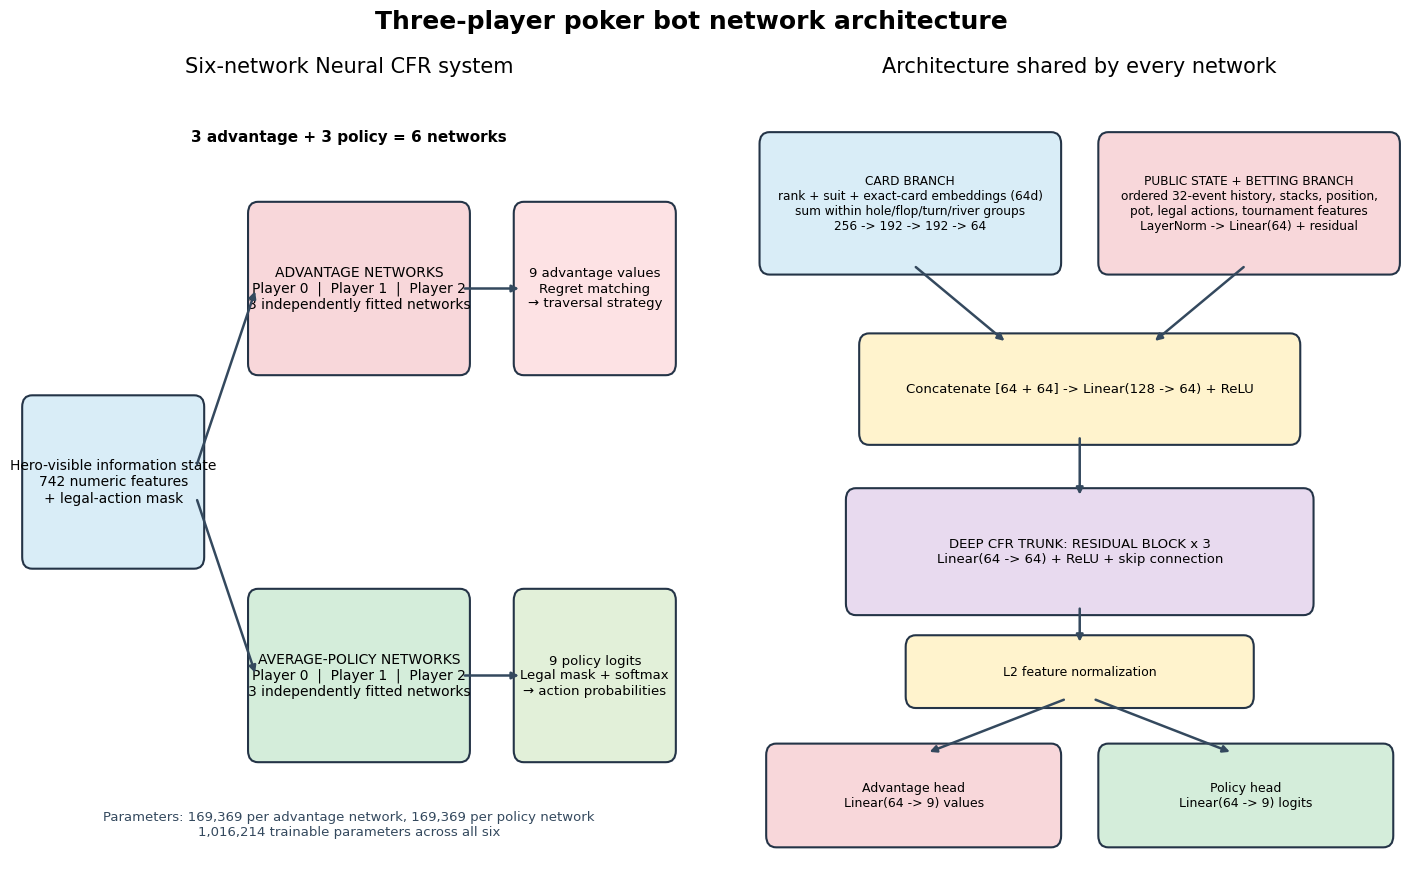

Saved architecture diagram to C:\Users\PRABAL YADAV\Desktop\absoloutlyCorrectButSlowCPUcfr\pokerCFR\artifacts\three_player_tournament_deep_cfr_bootstrap25_v1\network_architecture.png


In [6]:
architecture_figure = plot_network_architecture(trainer)
architecture_path = ARTIFACT_DIR / 'network_architecture.png'
architecture_figure.savefig(architecture_path, dpi=180, bbox_inches='tight')
display(architecture_figure)
plt.close(architecture_figure)
print(f'Saved architecture diagram to {architecture_path.resolve()}')

## 5. Live monitoring every N training iterations

At each `evaluate_every` boundary the dashboard is redrawn with an opponent-by-opponent table, confidence bounds, paired change, and BTN/SB/BB EV. Every configured number of completed evaluations, Cell 6 also prints and saves exact preflop call maps, a fold/call/raise composition chart, representative-hand frequencies, postflop call maps, and change since the previous range report. Held-out EV and its uncertainty are the primary improvement signals; the remaining plots are health and strategy diagnostics.

In [7]:
PERIODIC_PREFLOP_IDS = (
    'sb_vs_btn_open', 'bb_vs_btn_open_sb_fold',
    'bb_vs_btn_open_sb_call', 'btn_vs_bb_3bet',
)
PERIODIC_POSTFLOP_IDS = (
    'bb_hu_flop_vs_halfpot', 'btn_turn_vs_halfpot',
    'bb_river_vs_btn_pot',
)
LIVE_FLOP, LIVE_TURN, LIVE_RIVER = (51, 18, 0), 35, 41  # As-7d-2c-Jh-4s

def _display_figure(figure):
    display(figure)
    plt.close(figure)

def _human_duration(seconds):
    seconds = max(0, int(seconds))
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f'{hours:d}h {minutes:02d}m' if hours else f'{minutes:d}m {seconds:02d}s'

def save_periodic_strategy_report(evaluation_number):
    print(
        f'Generating live range report after evaluation {evaluation_number}: '
        'all physical card combinations, three policy networks...',
        flush=True,
    )
    periodic_analyzer = StrategyAnalyzer(trainer, batch_size=4096)
    preflop_catalog = {scenario.scenario_id: scenario for scenario in preflop_scenarios()}
    preflop_reports = periodic_analyzer.analyze_cases(
        [preflop_catalog[key] for key in PERIODIC_PREFLOP_IDS]
    )
    postflop_catalog = {
        scenario.scenario_id: scenario
        for scenario in postflop_scenarios(
            flop=LIVE_FLOP, turn=LIVE_TURN, river=LIVE_RIVER
        )
    }
    postflop_reports = periodic_analyzer.analyze_cases(
        [postflop_catalog[key] for key in PERIODIC_POSTFLOP_IDS]
    )
    reports = preflop_reports + postflop_reports
    report_root = ARTIFACT_DIR / 'strategy_analysis'
    report_dir = report_root / f'step_{trainer.iteration:08d}'
    report_dir.mkdir(parents=True, exist_ok=True)
    by_id = {report.scenario.scenario_id: report for report in reports}
    for report in reports:
        report.hand_table.to_csv(report_dir / f'{report.scenario.scenario_id}_169.csv', index=False)
    situation_table = pd.DataFrame([report.state_summary for report in reports])
    display(situation_table[[
        'label', 'hero_role', 'street', 'board', 'pot_bb', 'to_call_bb',
        'pot_odds', 'spr', 'physical_combos',
    ]])

    preflop_figure = plot_call_maps(preflop_reports)
    preflop_figure.savefig(report_dir / 'preflop_call_maps.png', dpi=160, bbox_inches='tight')
    _display_figure(preflop_figure)

    selected = by_id['bb_vs_btn_open_sb_call']
    mix_figure = plot_range_heatmaps(
        selected, metrics=('p_fold', 'p_call', 'p_aggressive')
    )
    mix_figure.savefig(report_dir / 'live_action_mix.png', dpi=160, bbox_inches='tight')
    _display_figure(mix_figure)
    representative_hands = ['AA', 'KK', 'QQ', 'AKs', 'AQs', 'AJo', 'TT', '76s', '22']
    hand_table = selected.hand_table.set_index('hand').reindex(representative_hands)
    display(hand_table[[
        'p_fold', 'p_call', 'p_aggressive', 'combo_std_p_call',
        'between_net_std_p_call',
    ]].style.format('{:.1%}'))

    postflop_figure = plot_call_maps(postflop_reports)
    postflop_figure.savefig(report_dir / 'postflop_call_maps.png', dpi=160, bbox_inches='tight')
    _display_figure(postflop_figure)
    previous_dirs = sorted(path for path in report_root.glob('step_*') if path.name < report_dir.name)
    if previous_dirs:
        scenario_id = 'bb_vs_btn_open_sb_call'
        previous_path = previous_dirs[-1] / f'{scenario_id}_169.csv'
        if previous_path.exists():
            previous = pd.read_csv(previous_path)
            current = by_id[scenario_id].hand_table
            change = previous[['hand', 'row', 'column', 'p_call']].merge(
                current[['hand', 'row', 'column', 'p_call']],
                on=['hand', 'row', 'column'], suffixes=('_previous', '_current'),
            )
            change['delta_p_call'] = change['p_call_current'] - change['p_call_previous']
            delta_figure = plot_range_delta(
                change, metric='delta_p_call',
                title='Call-frequency change since previous periodic report',
            )
            delta_figure.savefig(report_dir / 'call_delta_vs_previous_report.png', dpi=160, bbox_inches='tight')
            _display_figure(delta_figure)
    print(f'Live strategy report saved to {report_dir.resolve()}')

def show_existing_metrics():
    frame = metrics_frame(trainer.metrics)
    if frame.empty:
        print('No completed training iterations yet.')
        return
    display(frame.tail(10))
    dashboard = plot_training_dashboard(frame)
    _display_figure(dashboard)

def on_iteration(row):
    completed = trainer.iteration
    target = CAMPAIGN_CONFIG.target_iteration
    fraction = min(1.0, completed / max(target, 1))
    width = 28
    progress = '#' * int(width * fraction) + '-' * (width - int(width * fraction))
    recent = [float(item['seconds']) for item in trainer.metrics[-20:] if 'seconds' in item]
    eta = _human_duration((sum(recent) / max(len(recent), 1)) * max(target - completed, 0))
    current_ev = row.get('benchmark_composite_ev_bb')
    if current_ev is not None and math.isfinite(float(current_ev)):
        validation_text = f'{float(current_ev):+.4f} BB/hand (new evaluation)'
    else:
        latest = next((
            item for item in reversed(trainer.metrics)
            if item.get('benchmark_composite_ev_bb') is not None
            and math.isfinite(float(item['benchmark_composite_ev_bb']))
        ), None)
        until_evaluation = CAMPAIGN_CONFIG.evaluate_every - (completed % CAMPAIGN_CONFIG.evaluate_every)
        if latest is None:
            validation_text = f'pending; first evaluation in {until_evaluation} iterations'
        else:
            validation_text = (
                f"{float(latest['benchmark_composite_ev_bb']):+.4f} BB/hand "
                f"(last at iteration {int(latest['iteration'])}; next in {until_evaluation})"
            )
    completed_evaluations = sum(
        item.get('benchmark_composite_ev_bb') is not None
        and math.isfinite(float(item['benchmark_composite_ev_bb']))
        for item in trainer.metrics
    )
    if completed_evaluations and completed_evaluations % RANGE_PLOTS_EVERY_EVALS == 0 and current_ev is not None:
        range_text = 'range plots generating now'
    else:
        evaluations_until_ranges = RANGE_PLOTS_EVERY_EVALS - (completed_evaluations % RANGE_PLOTS_EVERY_EVALS)
        range_text = f'range plots in {evaluations_until_ranges} evaluation(s)'
    print(
        f'[{progress}] {100*fraction:6.2f}% | iteration {completed:,}/{target:,} | ETA ~{eta}\n'
        f"step {row['seconds']:.2f}s | nodes {int(row['nodes']):,} | "
        f"rollouts {int(row['rollouts']):,} | VRAM peak {row['gpu_peak_memory_mb']:.0f} MiB\n"
        f'validation composite: {validation_text} | {range_text}',
        flush=True,
    )

def on_evaluation(frame):
    clear_output(wait=True)
    evaluated = frame.dropna(subset=['benchmark_composite_ev_bb'])
    evaluation_number = len(evaluated)
    current = evaluated.iloc[-1]
    print(
        f'EVALUATION {evaluation_number} COMPLETE — training iteration {trainer.iteration:,} '
        f'of {CAMPAIGN_CONFIG.target_iteration:,}'
    )
    opponent_rows = []
    for profile in CAMPAIGN_CONFIG.opponent_profiles:
        opponent_rows.append({
            'opponent': profile.replace('_', ' '),
            'EV BB/hand': current[f'benchmark_{profile}_mean_ev_bb'],
            '95% low': current[f'benchmark_{profile}_ci95_low_bb'],
            '95% high': current[f'benchmark_{profile}_ci95_high_bb'],
            'delta vs initial': current[f'benchmark_{profile}_delta_ev_bb'],
            'P(delta > 0)': current[f'benchmark_{profile}_probability_delta_positive'],
            'BTN EV': current[f'benchmark_{profile}_ev_BTN_bb'],
            'SB EV': current[f'benchmark_{profile}_ev_SB_bb'],
            'BB EV': current[f'benchmark_{profile}_ev_BB_bb'],
        })
    display(pd.DataFrame(opponent_rows).style.format({
        'EV BB/hand': '{:+.3f}', '95% low': '{:+.3f}', '95% high': '{:+.3f}',
        'delta vs initial': '{:+.3f}', 'P(delta > 0)': '{:.1%}',
        'BTN EV': '{:+.3f}', 'SB EV': '{:+.3f}', 'BB EV': '{:+.3f}',
    }))
    columns = [
        'iteration', 'benchmark_composite_ev_bb',
        'benchmark_composite_lcb95_bb', 'league_mean_ev_bb',
        'league_worst_ev_bb', 'promoted_to_champion',
    ]
    display(evaluated[[column for column in columns if column in evaluated]].tail(10))
    dashboard = plot_training_dashboard(frame)
    _display_figure(dashboard)
    if evaluation_number % RANGE_PLOTS_EVERY_EVALS == 0:
        save_periodic_strategy_report(evaluation_number)
    else:
        remaining = RANGE_PLOTS_EVERY_EVALS - (evaluation_number % RANGE_PLOTS_EVERY_EVALS)
        print(f'Full hand/situation plots will refresh in {remaining} evaluation(s).')

show_existing_metrics()

No completed training iterations yet.


## 6. Run the resumable production campaign

This cell is intentionally long-running. A normal checkpoint is written every configured checkpoint interval. If you interrupt with `Ctrl+C`, the campaign writes a versioned emergency checkpoint before returning control. Hard power loss can lose only the work since the latest completed checkpoint.

EVALUATION 31 COMPLETE — training iteration 62 of 10,000


,opponent,EV BB/hand,95% low,95% high,delta vs initial,P(delta > 0),BTN EV,SB EV,BB EV
0,random,+8.623,+3.930,+13.316,+8.623,100.0%,-0.725,+21.538,+5.056
1,calling station,+1.388,-2.366,+5.142,-4.212,5.5%,+0.599,-4.320,+7.885
2,tight aggressive,-3.142,-6.159,-0.125,-4.290,0.9%,-0.852,-5.024,-3.550


,iteration,benchmark_composite_ev_bb,benchmark_composite_lcb95_bb,league_mean_ev_bb,league_worst_ev_bb,promoted_to_champion
43,44.0,4.165903,1.826496,NaN,NaN,0.0
45,46.0,3.379421,1.043139,NaN,NaN,0.0
47,48.0,1.792176,-0.542294,NaN,NaN,0.0
49,50.0,3.412454,1.020965,NaN,NaN,0.0
51,52.0,2.889653,0.631633,NaN,NaN,0.0
53,54.0,3.571806,1.269347,NaN,NaN,0.0
55,56.0,3.153785,0.877140,NaN,NaN,0.0
57,58.0,1.232211,-1.002735,NaN,NaN,0.0
59,60.0,2.169491,-0.197711,NaN,NaN,0.0
61,62.0,2.289722,0.048324,NaN,NaN,0.0


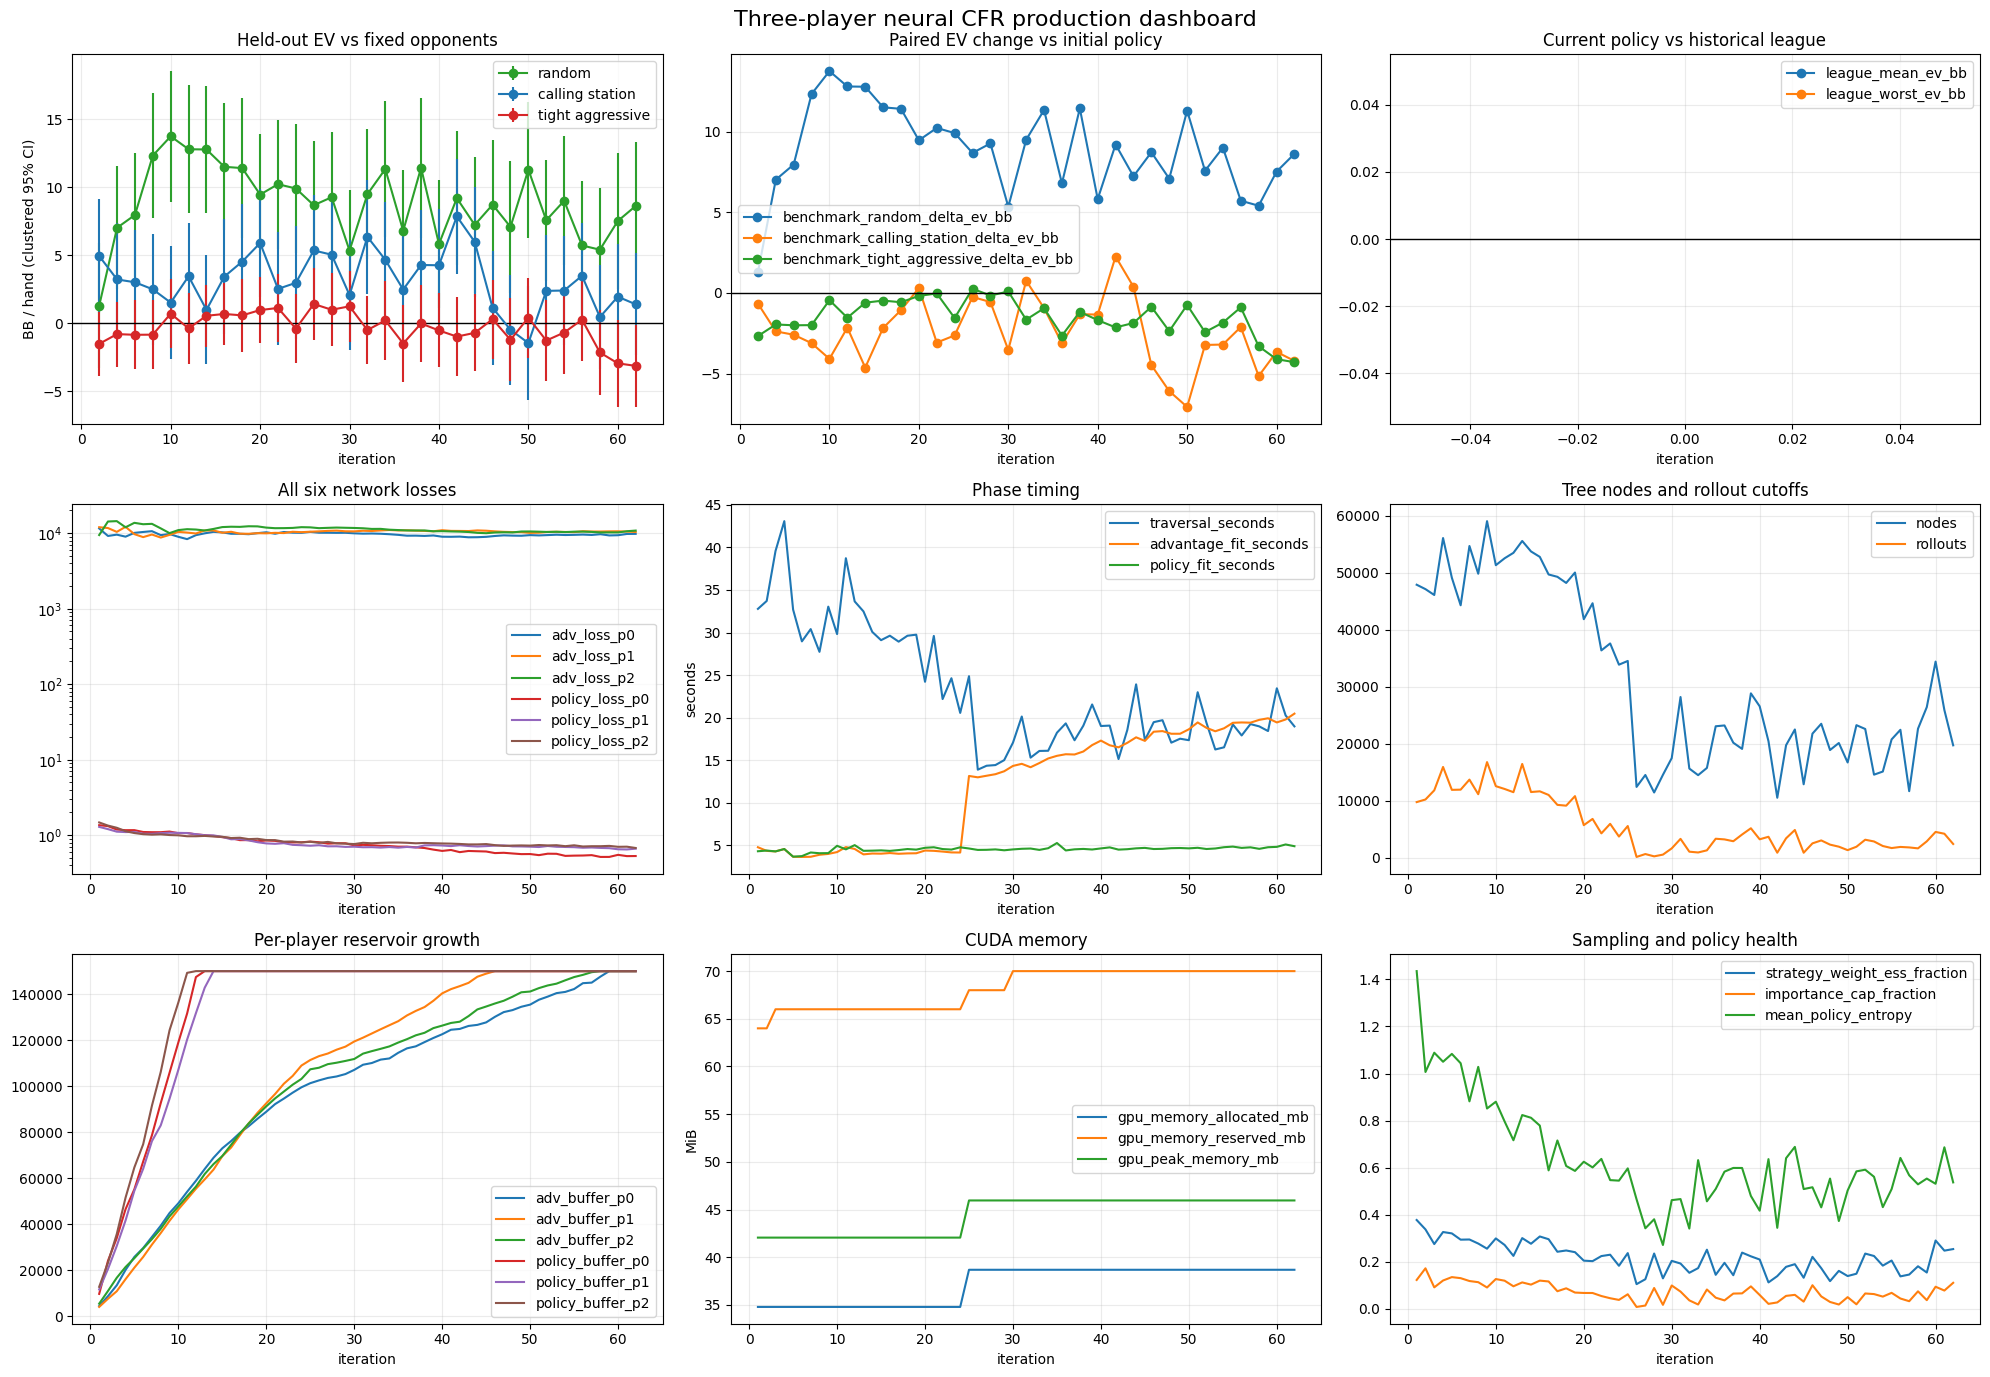

Generating live range report after evaluation 31: all physical card combinations, three policy networks...


,label,hero_role,street,board,pot_bb,to_call_bb,pot_odds,spr,physical_combos
0,SB facing BTN min-open,SB,0,,3.50,1.50,0.300000,28.000000,1326
1,"BB facing BTN open, SB folds",BB,0,,3.50,1.00,0.222222,28.000000,1326
2,BB facing BTN open + SB call,BB,0,,5.00,1.00,0.166667,19.600000,1326
3,BTN facing BB three-bet,BTN,0,,6.50,2.00,0.235294,14.769231,1326
4,BB heads-up facing BTN half-pot c-bet,BB,1,As 7d 2c,6.75,2.25,0.250000,14.185185,1176
5,BTN facing SB half-pot turn bet,BTN,2,As 7d 2c Jh,9.00,3.00,0.250000,10.555556,1128
6,BB facing BTN pot-size river bet,BB,3,As 7d 2c Jh 4s,9.00,4.50,0.333333,10.388889,1081


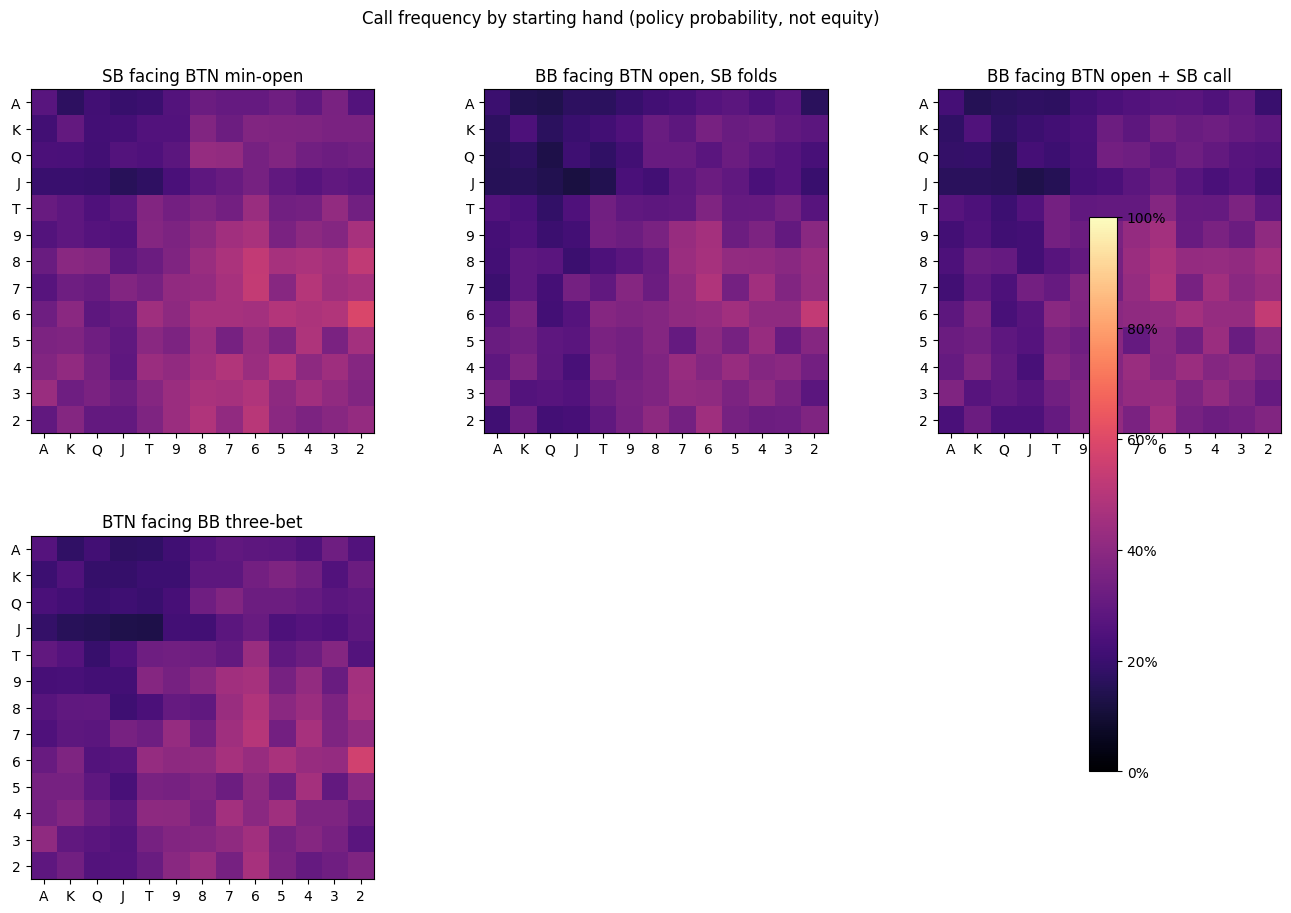

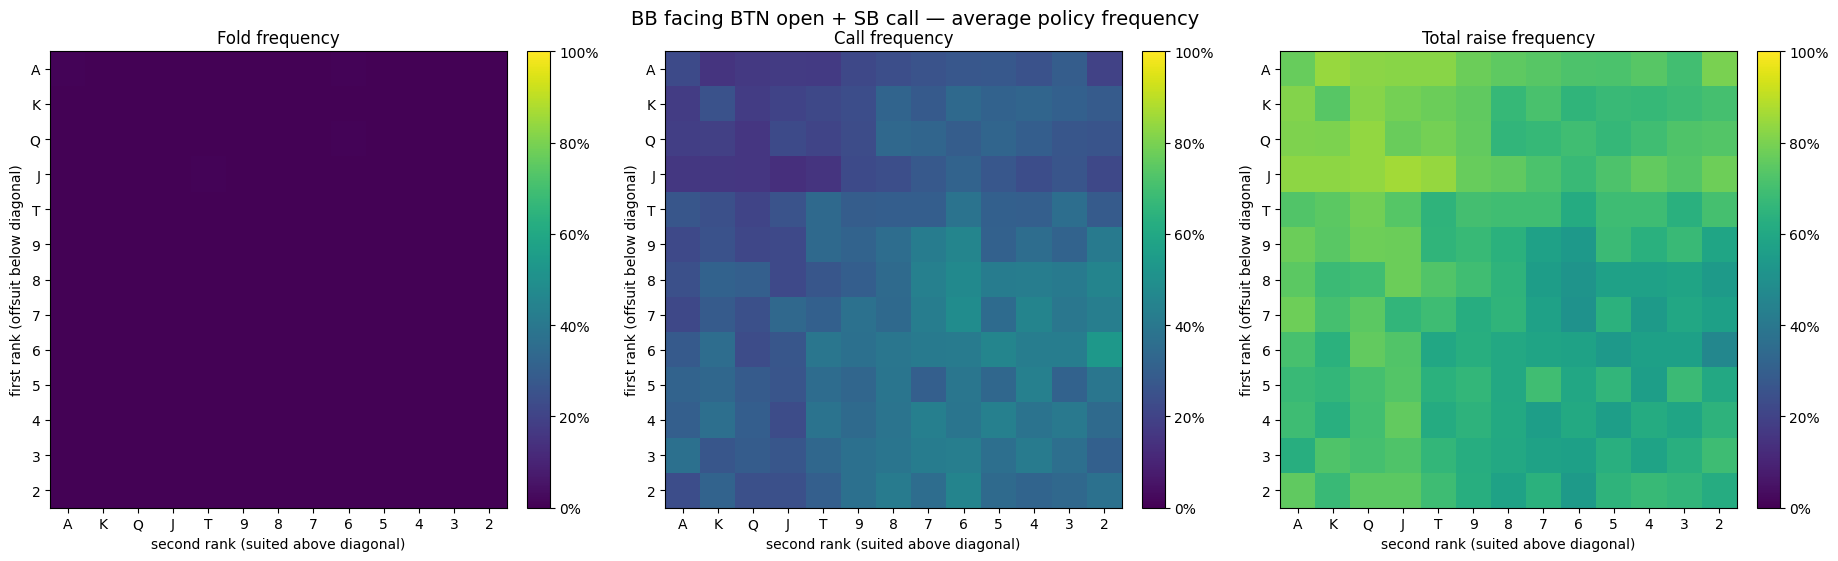

,p_fold,p_call,p_aggressive,combo_std_p_call,between_net_std_p_call
hand,,,,,
AA,0.9%,22.5%,76.6%,14.0%,10.3%
KK,0.5%,25.4%,74.1%,25.1%,20.2%
QQ,0.5%,15.9%,83.6%,10.3%,8.1%
AKs,0.5%,14.9%,84.6%,18.0%,5.9%
AQs,0.7%,16.7%,82.6%,10.2%,7.6%
AJo,0.6%,16.3%,83.1%,9.8%,6.9%
TT,0.5%,34.3%,65.2%,20.7%,9.8%
76s,0.5%,48.6%,50.9%,25.1%,17.9%
22,0.5%,37.4%,62.1%,21.8%,13.0%


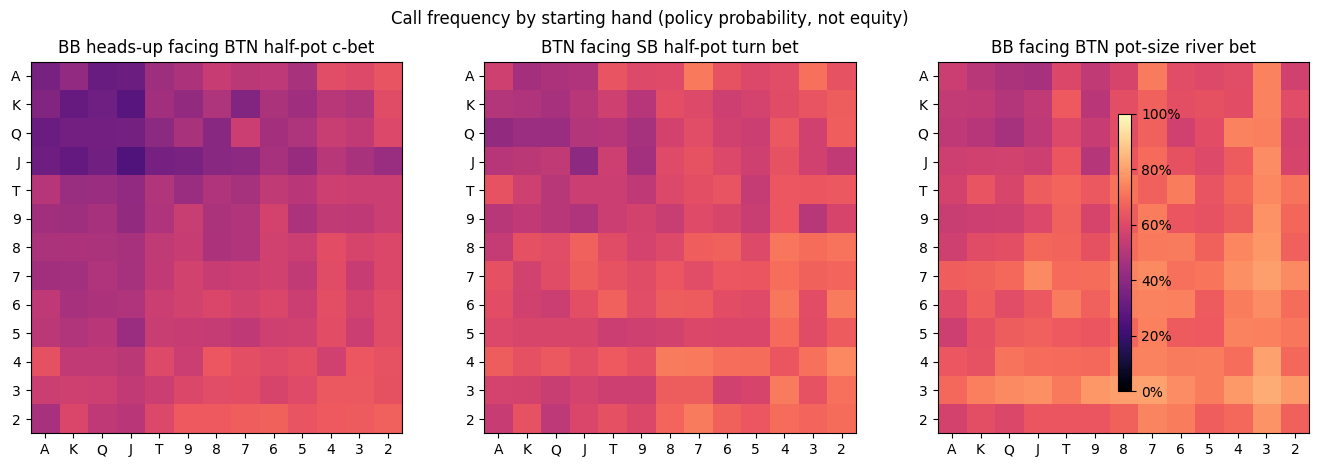

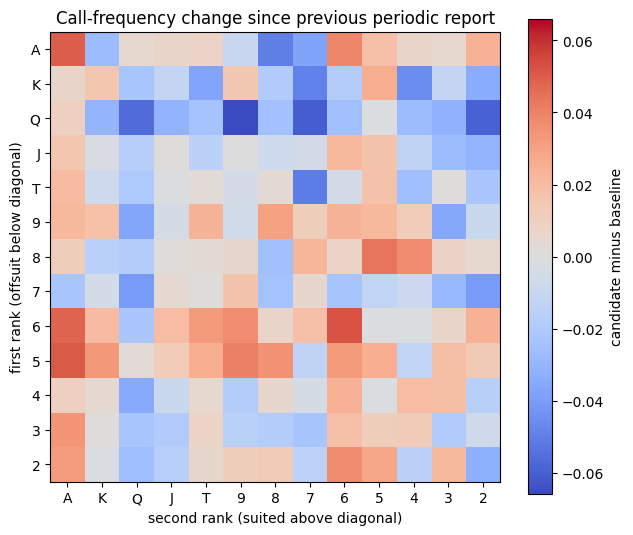

Live strategy report saved to C:\Users\PRABAL YADAV\Desktop\absoloutlyCorrectButSlowCPUcfr\pokerCFR\artifacts\three_player_tournament_deep_cfr_bootstrap25_v1\strategy_analysis\step_00000062


In [ ]:
campaign.run(on_iteration=on_iteration, on_evaluation=on_evaluation)
print(f'Reached iteration {trainer.iteration}; full state is checkpointed under {ARTIFACT_DIR}.')

In [ ]:
training_metrics = metrics_frame(trainer.metrics)
display(training_metrics.tail(20))
display(plot_training_dashboard(training_metrics))

## 7. Final held-out test suite

The validation seed above is repeatedly inspected and therefore must not be used for a final strength claim. Once the target is reached, this cell uses a different seed and a much larger hand count. Do not tune the model after looking at this result without assigning another untouched test seed.

In [ ]:
FINAL_TEST_GAMES_PER_PLAYER = int(os.getenv('POKER_FINAL_TEST_GAMES', '3000'))
FINAL_TEST_SEED = 909_731
if trainer.iteration >= CAMPAIGN_CONFIG.target_iteration:
    final_suite = evaluate_benchmark_suite(
        trainer, profiles=CAMPAIGN_CONFIG.opponent_profiles,
        games_per_player=FINAL_TEST_GAMES_PER_PLAYER, seed=FINAL_TEST_SEED,
    )
    final_rows = []
    for profile, result in final_suite.evaluations.items():
        final_rows.append({'opponent': profile, **result.summary})
    display(pd.DataFrame(final_rows))
else:
    print('Final holdout skipped: finish the configured target before opening the test set.')

## 8. Exact preflop call-frequency maps across 1,326 combinations

Each 13×13 cell averages all physical suit combinations: six for a pair, four for a suited hand, and twelve for an offsuit hand. Predictions are also averaged across all three independently trained policy networks. The upper triangle is suited, the diagonal is paired, and the lower triangle is offsuit.

In [ ]:
analyzer = StrategyAnalyzer(trainer, batch_size=4096)
analysis_dir = ARTIFACT_DIR / 'strategy_analysis' / f'step_{trainer.iteration:08d}'
analysis_dir.mkdir(parents=True, exist_ok=True)
preflop_catalog = {scenario.scenario_id: scenario for scenario in preflop_scenarios()}
bet_facing_ids = (
    'sb_vs_btn_open', 'bb_vs_btn_open_sb_fold',
    'bb_vs_btn_open_sb_call', 'btn_vs_bb_3bet',
)
preflop_reports = analyzer.analyze_cases([preflop_catalog[key] for key in bet_facing_ids])
for report in preflop_reports:
    report.hand_table.to_csv(analysis_dir / f'{report.scenario.scenario_id}_169.csv', index=False)
    report.combo_table.to_csv(analysis_dir / f'{report.scenario.scenario_id}_combos.csv', index=False)
display(pd.DataFrame([report.state_summary for report in preflop_reports]))
preflop_call_figure = plot_call_maps(preflop_reports)
preflop_call_figure.savefig(analysis_dir / 'preflop_call_maps.png', dpi=180, bbox_inches='tight')
display(preflop_call_figure)

## 9. Fold/call/raise composition in one named state

In [ ]:
selected_preflop = next(
    report for report in preflop_reports
    if report.scenario.scenario_id == 'bb_vs_btn_open_sb_call'
)
mix_figure = plot_range_heatmaps(
    selected_preflop, metrics=('p_fold', 'p_call', 'p_aggressive')
)
mix_figure.savefig(analysis_dir / 'bb_vs_open_call_action_mix.png', dpi=180, bbox_inches='tight')
display(mix_figure)

## 10. How the range changed from the frozen initial policy

This is a strategy-change diagnostic, not an improvement score. Red cells call more often than the initial policy; blue cells call less. Actual improvement is judged by the held-out EV dashboard above.

In [ ]:
baseline_preflop = analyzer.analyze_range(
    selected_preflop.scenario, policy_nets=campaign.baseline.policy_nets
)
preflop_change = compare_ranges(baseline_preflop, selected_preflop)
change_figure = plot_range_delta(
    preflop_change, metric='delta_p_call',
    title='Call-frequency change: current minus initial policy',
)
change_figure.savefig(analysis_dir / 'call_delta_vs_initial.png', dpi=180, bbox_inches='tight')
display(change_figure)
display(preflop_change.nlargest(20, 'strategy_total_variation')[
    ['hand', 'delta_p_fold', 'delta_p_call', 'delta_p_aggressive', 'strategy_total_variation']
])

## 11. Postflop call maps on fixed board textures

Postflop reports remove blocked hole-card combinations, replay the complete betting line through the engine, and show pot, amount to call, pot odds, effective stack, SPR, legal actions, and action targets. Change the board cards to inspect another texture.

In [ ]:
# Encoding is suit * 13 + rank, with ranks 2..A represented by 0..12.
FLOP = (51, 18, 0)   # As 7d 2c
TURN = 35            # Jh
RIVER = 41           # 4s
postflop_catalog = {
    scenario.scenario_id: scenario
    for scenario in postflop_scenarios(flop=FLOP, turn=TURN, river=RIVER)
}
postflop_ids = (
    'btn_flop_vs_bet_call', 'bb_hu_flop_vs_halfpot',
    'btn_turn_vs_halfpot', 'bb_river_vs_btn_pot',
)
postflop_reports = analyzer.analyze_cases([postflop_catalog[key] for key in postflop_ids])
for report in postflop_reports:
    report.hand_table.to_csv(analysis_dir / f'{report.scenario.scenario_id}_169.csv', index=False)
display(pd.DataFrame([report.state_summary for report in postflop_reports]))
postflop_call_figure = plot_call_maps(postflop_reports)
postflop_call_figure.savefig(analysis_dir / 'postflop_call_maps.png', dpi=180, bbox_inches='tight')
display(postflop_call_figure)

## 12. Sensitivity to every possible turn card

For a fixed AcKc hand on As-7d-2c, this chart varies all 47 legal turn cards and reports the bot's call frequency when facing the configured half-pot turn bet. Blocked cards remain blank.

In [ ]:
turn_scenario = postflop_catalog['btn_turn_vs_halfpot']
turn_sweep = analyzer.analyze_next_cards(
    turn_scenario, hero_cards=(12, 11)  # Ac Kc
)
turn_sweep.to_csv(analysis_dir / 'AcKc_turn_card_sweep.csv', index=False)
turn_figure = plot_card_sweep(
    turn_sweep, metric='p_call',
    title='AcKc on As-7d-2c: call frequency by turn card',
)
turn_figure.savefig(analysis_dir / 'AcKc_turn_call_sweep.png', dpi=180, bbox_inches='tight')
display(turn_figure)

## 13. Detect disagreement between the three player networks

Large between-network variation for equivalent role-relative spots is a warning that one network is under-trained or has learned suit/seat artifacts.

In [ ]:
divergence_columns = [
    'hand', 'p_call', 'p_aggressive',
    'combo_std_p_call', 'between_net_std_p_call',
    'between_net_std_p_aggressive',
]
display(
    selected_preflop.hand_table
    .sort_values('between_net_std_p_call', ascending=False)
    [divergence_columns].head(30)
)

## 14. Held-out human match protocol

To claim that the bot beats humans, record a separate match dataset with columns `hand_id`, `session_id`, `bot_seat`, `button`, `opponent_pool`, and `payoff_bb`. Rotate seats and the button evenly, do not train on these hands during the test, and predeclare the stopping hand count. A useful first target is tens of thousands of hands; poker variance makes a few hundred hands nearly meaningless.

The cell below reads `artifacts/human_matches.csv` when available and calculates a session-clustered interval. A positive mean is not enough—the lower confidence bound should also be above zero on an untouched test.

In [ ]:
HUMAN_MATCH_PATH = Path('artifacts/human_matches.csv')
if HUMAN_MATCH_PATH.exists():
    human = pd.read_csv(HUMAN_MATCH_PATH)
    required = {'hand_id', 'session_id', 'bot_seat', 'button', 'opponent_pool', 'payoff_bb'}
    missing = required - set(human.columns)
    if missing:
        raise ValueError(f'Human match log is missing columns: {sorted(missing)}')
    session_means = human.groupby('session_id')['payoff_bb'].mean()
    mean_ev = float(human['payoff_bb'].mean())
    session_se = float(session_means.std(ddof=1) / math.sqrt(len(session_means))) if len(session_means) > 1 else float('nan')
    display(pd.Series({
        'hands': len(human), 'sessions': human['session_id'].nunique(),
        'mean BB/hand': mean_ev, 'BB/100': 100 * mean_ev,
        'clustered SE': session_se,
        '95% CI low': mean_ev - 1.96 * session_se,
        '95% CI high': mean_ev + 1.96 * session_se,
    }, name='held-out human match'))
    human.assign(cumulative_bb=human['payoff_bb'].cumsum()).plot(
        x='hand_id', y='cumulative_bb', figsize=(12, 4),
        title='Cumulative held-out human-match result', grid=True,
    )
    plt.show()
else:
    print(f'No human match log yet. Expected schema at {HUMAN_MATCH_PATH.resolve()}:')
    display(pd.DataFrame(columns=[
        'hand_id', 'session_id', 'bot_seat', 'button',
        'opponent_pool', 'payoff_bb',
    ]))

## 15. Deployment and remaining engineering boundary

The deployable artifact is `snapshots/champion_policy.pt`, containing only the three average-policy networks. Full checkpoints are for training recovery and include large replay reservoirs. The champion is promoted when its confidence-adjusted composite validation score exceeds the previous champion.

This creates a strong research and production-training workflow, but it does not guarantee a human-beating bot. Before real deployment, add a poker client, time controls, action logging, security boundaries, and either constrain humans to the same nine-action game or implement and validate arbitrary-bet translation/real-time resolving. Continue to use a completely unseen test suite for final selection.

In [ ]:
artifact_inventory = {
    'run configuration': ARTIFACT_DIR / 'run_config.json',
    'latest checkpoint manifest': ARTIFACT_DIR / 'latest.json',
    'initial frozen policy': ARTIFACT_DIR / 'snapshots' / 'initial_policy.pt',
    'validation champion': ARTIFACT_DIR / 'snapshots' / 'champion_policy.pt',
    'append-only metrics': ARTIFACT_DIR / 'metrics.jsonl',
    'strategy reports': analysis_dir,
}
display(pd.Series({key: str(path.resolve()) for key, path in artifact_inventory.items()}, name='artifacts'))